### Predicting Storm Occurrence Using Random Forest Classifier

In this section, we aim to build a classification model to predict **whether or not a tropical storm will occur** using a **Random Forest Classifier** and based on based on climate-related variables such as CO₂ emissions, monthly global surface temperatures, and date information (year, month, day). This binary prediction forms the first part of a two-step pipeline, where the second part predicts storm intensity if a storm is expected.

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from itertools import product


### Load and Explore the Dataset
We begin by loading the merged dataset completed_dataset_for_IS_project_25.csv, which includes data from historical storm records, global temperatures, and CO₂ emissions. A quick preview helps ensure the dataset loads correctly and has all necessary columns.

In [ ]:
# Load original dataset
data = pd.read_csv("completed_dataset_for_IS_project_25.csv")
print("Original storm-only dataset shape:", data.shape)

# Mark all rows as storm occurred
data["storm_occured"] = 1

# Generate dummy no-storm rows (20-degree offset + random dates)
years = range(data["Year"].min(), data["Year"].max() + 1)
months = range(1, 13)
days = range(1, 32)
lats = np.arange(data["LAT"].min(), data["LAT"].max(), 20.0)
longs = np.arange(data["LONG"].min(), data["LONG"].max(), 20.0)

def valid_date(row):
    month, day, year = row["MONTH"], row["DAY"], row["Year"]
    if month < 1 or month > 12: return False
    if month in [1, 3, 5, 7, 8, 10, 12] and not (1 <= day <= 31): return False
    if month in [4, 6, 9, 11] and not (1 <= day <= 30): return False
    if month == 2:
        leap = (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0)
        return 1 <= day <= (29 if leap else 28)
    return True

# Generate Cartesian product of combinations
new_rows = pd.DataFrame(product(years, months, days, lats, longs), columns=["Year", "MONTH", "DAY", "LAT", "LONG"])
new_rows = new_rows[new_rows.apply(valid_date, axis=1)]

# Remove dates/locations where a storm actually occurred
storm_info = data[["Year", "MONTH", "DAY", "LAT", "LONG"]].drop_duplicates()
merged = pd.merge(new_rows, storm_info, how="left", on=["Year", "MONTH", "DAY", "LAT", "LONG"], indicator=True)
no_storms = merged[merged["_merge"] == "left_only"].drop(columns=["_merge"])


# Initialize dummy storm-related values
no_storms["storm_occured"] = 0
no_storms["WIND_KTS"] = 0
no_storms["CAT"] = "NA"
no_storms["Storm Intensity"] = 0.0
no_storms["Storm Intensity Label"] = 0

# Fill in average temp + CO2 values
for col in ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec", "CO2 emission (Tons)"]:
    no_storms[col] = data[col].mean()

# Merge both datasets
data = pd.concat([data, no_storms], ignore_index=True)
data = shuffle(data, random_state=42).reset_index(drop=True)

print("Combined dataset (storms + no storms):", data.shape)

### Define Target and Feature Variables
To enable storm occurrence classification, we:

Define the binary target variable storm_occured, which indicates whether a storm was present (1) or not (0).

Select feature columns that include:
Temporal variables (Year, MONTH, DAY)
Environmental variables (CO2 emission (Tons))
Monthly surface temperature anomalies (Jan to Dec)

We drop features related to storm severity (Storm Intensity, Storm Intensity Label, WIND_KTS, etc.) to prevent data leakage during occurrence prediction.

In [ ]:
# Drop irrelevant columns & set up features
features = [
    "Year", "MONTH", "DAY", "CO2 emission (Tons)",
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]
target = "storm_occured"

X = data[features]
y = data[target]

### Split the Dataset (Train/Val/Test)
To validate model performance robustly, the dataset is split into:

Training Set (70%)

Validation Set (15%)

Test Set (15%)

We use stratified sampling to ensure that both classes (storm/no storm) are equally represented across splits, avoiding class imbalance issues that might skew the model.

In [47]:
# Shuffle the entire dataset to ensure randomness
shuffled_data = shuffle(data, random_state=42).reset_index(drop=True)

# Determine row cutoffs
train_end = int(0.7 * len(shuffled_data))
val_end = int(0.85 * len(shuffled_data))

# Create splits with no overlap
train_data = shuffled_data.iloc[:train_end]
val_data = shuffled_data.iloc[train_end:val_end]
test_data = shuffled_data.iloc[val_end:]

# Separate features and target
X_train = train_data[features]
y_train = train_data[target]
X_val = val_data[features]
y_val = val_data[target]
X_test = test_data[features]
y_test = test_data[target]

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


Train size: 2411555
Validation size: 516762
Test size: 516762


### Train the Random Forest Classifier
We train a Random Forest Classifier with the following settings:

n_estimators=100: the number of decision trees in the forest
max_depth=8: limits tree depth to reduce overfitting
random_state=5: for reproducibility

This ensemble method is chosen for its robustness, ability to handle nonlinear relationships, and interpretability.

In [48]:
# Initialize model with basic hyperparameters
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=8)
model_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, random_state=42)

### Evaluate the Model (Test Set)
We evaluate our trained model on the unseen test set, using the following metrics:

Accuracy: Overall correctness
Precision: Focus on minimizing false positives
F1-Score: Balance between precision and recall
Latency: How quickly the model generates predictions

This helps us assess real-world performance in both correctness and responsiveness.

In [49]:
# Test Set Evaluation
start_time = time.time()
y_pred_test = model_rf.predict(X_test)
latency_test = time.time() - start_time

print("📊 Evaluation on Test Set")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_test):.4f}")
print(f"Latency: {latency_test:.4f} seconds")

📊 Evaluation on Test Set
Accuracy: 1.0000
Precision: 1.0000
F1 Score: 1.0000
Latency: 1.0623 seconds


### Visualize with a Confusion Matrix
We plot a confusion matrix to gain deeper insight into the model's predictions:

True Positives (TP): Storms correctly predicted

True Negatives (TN): No storms correctly identified

False Positives (FP): Predicted storm when there was none

False Negatives (FN): Missed storm predictions

This allows us to understand where the model performs well and where it might need improvement.

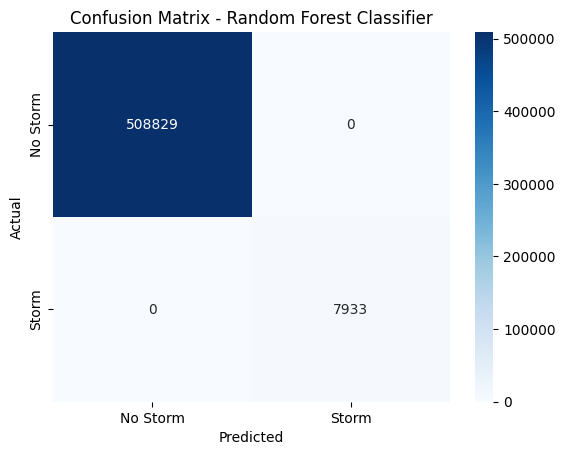

In [50]:
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["No Storm", "Storm"], yticklabels=["No Storm", "Storm"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()

### Detailed Classification Report
We generate a classification report showing:

Precision, Recall, and F1-score for each class

Support: Number of actual samples in each class

Both macro and weighted averages, giving a full picture of model behavior, especially in the presence of any class imbalance.

In [51]:
print("📝 Classification Report")
print(classification_report(y_test, y_pred_test, target_names=["No Storm", "Storm"]))

📝 Classification Report
              precision    recall  f1-score   support

    No Storm       1.00      1.00      1.00    508829
       Storm       1.00      1.00      1.00      7933

    accuracy                           1.00    516762
   macro avg       1.00      1.00      1.00    516762
weighted avg       1.00      1.00      1.00    516762



### Define a User Prediction Function
We build a reusable function predict_storm_rf() that allows users to input:

A date (year, month, day)

A CO₂ emissions estimate

A dictionary of temperature anomalies for each month

This function returns a prediction (0 or 1) indicating whether a storm is expected, making the model interactive and deployable.

In [52]:
def predict_storm_rf(model, year, month, day, co2, temps_dict):
    input_dict = {
        "Year": [year],
        "MONTH": [month],
        "DAY": [day],
        "CO2 emission (Tons)": [co2]
    }

    for month_name in ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                       "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]:
        input_dict[month_name] = [temps_dict.get(month_name, 0)]

    input_df = pd.DataFrame(input_dict)
    prediction = model.predict(input_df)[0]
    return prediction


### Try Sample Predictions
We simulate two examples:

A storm-possible scenario with high CO₂ and warm temperatures

A storm-unlikely scenario with low CO₂ and cooler temperatures

This demonstrates the model’s usability and how climate conditions influence storm prediction in a practical setting.

In [53]:
sample_temp = {
    "Jan": -0.19, "Feb": -0.25, "Mar": -0.09, "Apr": -0.17, "May": -0.10,
    "Jun": -0.21, "Jul": -0.18, "Aug": -0.11, "Sep": -0.15,
    "Oct": -0.24, "Nov": -0.22, "Dec": -0.18
}

storm_occurred = predict_storm_rf(model_rf, 1995, 8, 14, 2.3e9, sample_temp)
print("🌪️ A storm was predicted!" if storm_occurred else "☀️ No storm was predicted!")


🌪️ A storm was predicted!


### Summary
This section of the project successfully built a classification model to predict the occurrence of tropical storms based on environmental and temporal variables. Random Forest was selected for its robustness and interpretability.

Next step: In Part 2, we will build a Random Forest Regressor to predict storm intensity for instances where a storm is predicted to occur.

### Part 2: Predicting Tropical Storm Intensity (Random Forest Regressor)
In this section, we aim to predict the **intensity label** of a tropical storm once its occurrence has been confirmed (i.e., `storm_occured = 1`). Using features such as CO₂ emissions, storm category, wind speed, and temporal data, we train a Random Forest Regressor to predict the `Storm Intensity Label`.

The model is trained using a 70/15/15 split and evaluated on the test set using standard regression metrics: **MSE**, **MAE**, and **R² score**.

We also provide a function to predict intensity for new storm inputs.

### *Filter Dataset for Storm Records Only*

We begin by filtering the dataset to only include records where a tropical storm occurred. We further restrict the records to include only those where the Storm Intensity Label falls within a valid range (1 to 5), as values outside this range are either not storms or represent extreme outliers.


In [54]:
# Only use rows where a storm occurred and intensity label is within valid range
storms = data[
    (data["storm_occured"] == 1) &
    (data["Storm Intensity Label"] >= 1) &
    (data["Storm Intensity Label"] <= 5)
].copy()

print("Filtered dataset shape (storm records only):", storms.shape)


Filtered dataset shape (storm records only): (47028, 27)


### Encode Categorical Features
The CAT column contains storm category types as string labels (e.g., "TS", "H1", "H2"). These need to be converted into numerical values using label encoding so the model can process them as features.

In [55]:
from sklearn.preprocessing import LabelEncoder

# Encode storm category to a numerical format
le = LabelEncoder()
storms["CAT_int"] = le.fit_transform(storms["CAT"].astype(str))

print("Unique storm categories:", list(le.classes_))


Unique storm categories: ['H1', 'H2', 'H3', 'SD', 'SS', 'TD', 'TS']


### Define Features and Target Variables
We define our feature set X and target variable y. For intensity prediction, the target variable is Storm Intensity Label, and the features include encoded storm category, year, month, day, CO₂ emissions, and wind speed (WIND_KTS).

In [56]:
# Define features and target WITHOUT 'CAT_int' or 'WIND_KTS' to avoid leakage
X_intensity = storms[["Year", "MONTH", "DAY", "CO2 emission (Tons)"]]
y_intensity = storms["Storm Intensity Label"]

# Drop potential duplicates
combined = pd.concat([X_intensity, y_intensity], axis=1)
combined = combined.drop_duplicates(subset=["Year", "MONTH", "DAY", "CO2 emission (Tons)"])

X_intensity = combined[["Year", "MONTH", "DAY", "CO2 emission (Tons)"]]
y_intensity = combined["Storm Intensity Label"]

# Shuffle before splitting
X_intensity, y_intensity = shuffle(X_intensity, y_intensity, random_state=42)



### Split Data into Train, Validation, and Test Sets
The dataset is split into 70% for training, 15% for validation, and 15% for testing. This split ensures the model is trained and fine-tuned on separate subsets of the data before being evaluated on unseen data.

In [57]:
# 70% train, 15% validation, 15% test
X_train_int, X_temp_int, y_train_int, y_temp_int = train_test_split(
    X_intensity, y_intensity, test_size=0.30, random_state=42
)
X_val_int, X_test_int, y_val_int, y_test_int = train_test_split(
    X_temp_int, y_temp_int, test_size=0.50, random_state=42
)

print(f"Train size: {len(X_train_int)}")
print(f"Validation size: {len(X_val_int)}")
print(f"Test size: {len(X_test_int)}")


Train size: 10245
Validation size: 2195
Test size: 2196


### Train Random Forest Regressor
We use the Random Forest Regressor to learn the relationship between input features and storm intensity. This ensemble learning method creates multiple decision trees and averages their outputs for more stable and accurate predictions.

In [58]:
# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_int, y_train_int)

RandomForestRegressor(random_state=42)

### Evaluate Model on Validation Set
We evaluate the model’s performance using Mean Squared Error (MSE), Mean Absolute Error (MAE), and R² score on the validation set. We also capture the latency (execution time) to assess the model’s efficiency.


In [59]:
# Evaluate on validation data
start_val = time.time()
y_pred_val_int = rf_model.predict(X_val_int)
val_latency = time.time() - start_val

print("📊 Validation Performance")
print("MSE:", mean_squared_error(y_val_int, y_pred_val_int))
print("MAE:", mean_absolute_error(y_val_int, y_pred_val_int))
print("R² Score:", r2_score(y_val_int, y_pred_val_int))
print("Latency:", val_latency, "seconds")


📊 Validation Performance
MSE: 0.790783325740319
MAE: 0.6595626423690205
R² Score: 0.3164553128452471
Latency: 0.0625159740447998 seconds


### Evaluate Model on Test Set
The model is then tested on the final hold-out set to get an unbiased estimate of its performance. The same metrics (MSE, MAE, R² score, latency) are used to validate how well the model generalizes to new data.

In [60]:
# Evaluate on test data
start_test = time.time()
y_pred_test_int = rf_model.predict(X_test_int)
test_latency = time.time() - start_test

print("\n📊 Test Performance")
print("MSE:", mean_squared_error(y_test_int, y_pred_test_int))
print("MAE:", mean_absolute_error(y_test_int, y_pred_test_int))
print("R² Score:", r2_score(y_test_int, y_pred_test_int))
print("Latency:", test_latency, "seconds")



📊 Test Performance
MSE: 0.7778277322404371
MAE: 0.6582559198542804
R² Score: 0.3270033218793196
Latency: 0.05867624282836914 seconds


### Predict Storm Intensity for New Input
We define a helper function predict_intensity() that allows us to input real-world storm conditions (e.g., category, date, CO₂ levels) and output the predicted storm intensity label. This simulates how the model could be used in practice after deployment.

In [63]:
def predict_intensity(model, co2, year, month, day):
    input_df = pd.DataFrame([{
        "Year": year,
        "MONTH": month,
        "DAY": day,
        "CO2 emission (Tons)": co2
    }])
    return model.predict(input_df)[0]

# Example usage
predicted_intensity = predict_intensity(
    model=rf_model,
    co2=2.7e9,
    year=2024,
    month=8,
    day=14
)
print(f"Predicted Storm Intensity Label: {predicted_intensity:.2f}")


Predicted Storm Intensity Label: 2.94
